# Regressão com MLP — Admissão em Pós-Graduação

Nesse notebook eu uso a biblioteca MLP que a gente construiu do zero pra prever a chance de admissão de um estudante numa pós-graduação. O alvo é um valor contínuo entre 0 e 1, então é um problema de regressão, ele prevê um número.

Dataset: `Admission_Predict.csv` com 500 amostras. As features são nota no GRE, TOEFL, avaliação da universidade, SOP, LOR, CGPA e se o estudante tem pesquisa.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from mlp import (
    MLP, Dense,
    ReLU, Identity,
    MeanSquaredError,
    HeNormal,
    GradientDescent,
    mse, r2_score,
)

print('Imports OK — project_root:', project_root)

Imports OK — project_root: /Users/rafaelaborges/Documents/Projects/AM-


## 1. Carregamento e limpeza do dataset

O CSV tem uma coluna `Serial No.` que é só índice, então descarto ela. O nome da coluna `LOR` vem com um espaço no final no arquivo original, então faço um strip nos nomes das colunas na leitura.

In [ ]:
import csv

# Caminho relativo ao project_root
csv_path = os.path.join(project_root, 'data', 'Admission_Predict.csv')

rows = []
with open(csv_path, newline='') as f:
    reader = csv.DictReader(f)
    # strip() remove o espaço extra em LOR e qualquer outro nome com espaço
    reader.fieldnames = [name.strip() for name in reader.fieldnames]
    for row in reader:
        rows.append(row)

feature_cols = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']
target_col   = 'Chance of Admit'

# 'Serial No.' é descartado: não entra em feature_cols
X = np.array([[float(r[c]) for c in feature_cols] for r in rows])  # (500, 7)
y = np.array([float(r[target_col]) for r in rows])                  # (500,)

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'y  min={y.min():.2f}  max={y.max():.2f}  média={y.mean():.3f}')

X shape: (500, 7)  |  y shape: (500,)
y  min=0.34  max=0.97  média=0.722


## 2. Shuffle, split treino/teste e padronização (z-score)

Primeiro embaralho os dados com uma semente fixa pra garantir que o resultado seja reproduzível. Depois divido em 80% treino e 20% teste.

A padronização (z-score) é feita só com os dados de treino, calculo média e desvio padrão do treino e aplico essa mesma escala no teste. Se eu usasse as estatísticas do teste pra normalizar, estaria "vazando" informação do teste pro modelo antes da avaliação.

In [ ]:
# Passo 1: Embaralha com semente fixa para reprodutibilidade
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

# Passo 2: Split 80/20 depois de embaralhar
n_train = int(0.8 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f'Treino: {X_train.shape}  |  Teste: {X_test.shape}')

# Passo 3: Z-score: fit somente no treino.
# Usar stats do teste contaminaria a avaliação (data leakage).
mean_train = X_train.mean(axis=0)
std_train  = X_train.std(axis=0)

X_train_s = (X_train - mean_train) / std_train  # padroniza treino
X_test_s  = (X_test  - mean_train) / std_train  # aplica mesma escala no teste

# O alvo já está em [0, 1] — não precisa escalar
print(f'Média X_train_s ≈ 0: {X_train_s.mean(axis=0).round(3)}')
print(f'Std   X_train_s ≈ 1: {X_train_s.std(axis=0).round(3)}')

Treino: (400, 7)  |  Teste: (100, 7)
Média X_train_s ≈ 0: [ 0.  0. -0.  0.  0.  0.  0.]
Std   X_train_s ≈ 1: [1. 1. 1. 1. 1. 1. 1.]


## 3. Definição do modelo

A rede tem 3 camadas: duas ocultas com ReLU e uma de saída com Identity. Uso ReLU nas camadas ocultas porque funciona bem pra capturar não-linearidades, e Identity na saída porque é regressão.

A inicialização He Normal é recomendada pra redes com ReLU porque leva em conta que metade dos neurônios ficam zerados, então ajusta a variância dos pesos pra compensar.

In [ ]:
# Arquitetura: 7 -> 32(ReLU) -> 16(ReLU) -> 1(Identity)
# He Normal é a inicialização recomendada para ReLU
# Identity na saída mantém o valor contínuo (regressão)
model = MLP()
model.add(Dense(32, activation=ReLU(),      initializer=HeNormal(seed=42)))
model.add(Dense(16, activation=ReLU(),      initializer=HeNormal(seed=7)))
model.add(Dense(1,  activation=Identity(),  initializer=HeNormal(seed=0)))

model.compile(
    loss=MeanSquaredError(),
    optimizer=GradientDescent(learning_rate=0.01),
    metric=None,  # metric=None desativa accuracy — modo regressão
)

print('Modelo: 7 → 32(ReLU) → 16(ReLU) → 1(Identity)')
print('Custo: MeanSquaredError  |  Otimizador: GradientDescent(lr=0.01)')

Modelo: 7 → 32(ReLU) → 16(ReLU) → 1(Identity)
Custo: MeanSquaredError  |  Otimizador: GradientDescent(lr=0.01)


## 4. Treinamento

Treino por 500 épocas com mini-batches de 32 amostras. Passo o conjunto de teste como validação pra acompanhar se o modelo tá generalizando ou só decorando o treino.

In [5]:
history = model.fit(
    X_train_s, y_train,
    epochs=500,
    batch_size=32,
    shuffle=True,
    verbose=True,
    validation_data=(X_test_s, y_test),
)

print(f'\nLoss final (treino): {history["loss"][-1]:.6f}')
print(f'Loss final (val):    {history["val_loss"][-1]:.6f}')

epoch    0  loss 0.2282  val_loss 0.2392
epoch   25  loss 0.0169  val_loss 0.0208
epoch   50  loss 0.0094  val_loss 0.0115
epoch   75  loss 0.0068  val_loss 0.0083
epoch  100  loss 0.0056  val_loss 0.0072
epoch  125  loss 0.0050  val_loss 0.0064
epoch  150  loss 0.0046  val_loss 0.0060
epoch  175  loss 0.0043  val_loss 0.0057
epoch  200  loss 0.0041  val_loss 0.0056
epoch  225  loss 0.0040  val_loss 0.0054
epoch  250  loss 0.0038  val_loss 0.0053
epoch  275  loss 0.0038  val_loss 0.0052
epoch  300  loss 0.0037  val_loss 0.0051
epoch  325  loss 0.0036  val_loss 0.0050
epoch  350  loss 0.0035  val_loss 0.0050
epoch  375  loss 0.0035  val_loss 0.0049
epoch  400  loss 0.0034  val_loss 0.0049
epoch  425  loss 0.0034  val_loss 0.0048
epoch  450  loss 0.0034  val_loss 0.0048
epoch  475  loss 0.0034  val_loss 0.0048
epoch  499  loss 0.0033  val_loss 0.0048

Loss final (treino): 0.003311
Loss final (val):    0.004770


## 5. Curva de loss

Ploto a loss de treino e validação ao longo das épocas. As duas curvas caindo juntas é um bom sinal, significa que o modelo tá aprendendo sem overfitting.

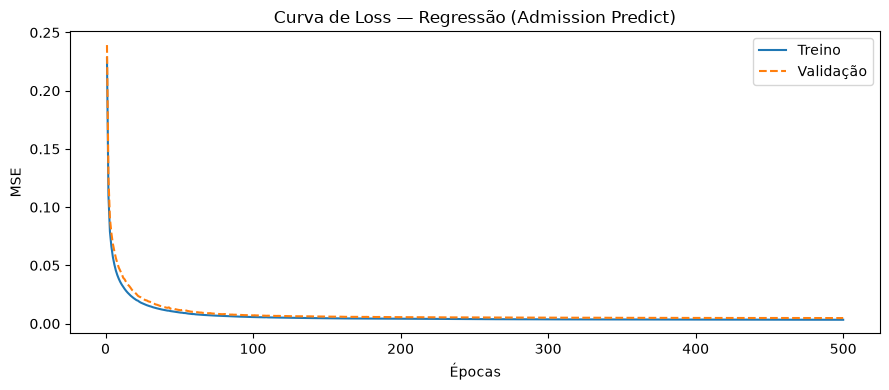

In [6]:
epochs_range = range(1, len(history['loss']) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs_range, history['loss'],     label='Treino',    linewidth=1.5)
plt.plot(epochs_range, history['val_loss'], label='Validação', linewidth=1.5, linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Curva de Loss — Regressão (Admission Predict)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Avaliação no conjunto de teste

Avalio o modelo com três métricas: MSE, RMSE e R². O RMSE é útil porque fica na mesma escala do alvo (0 a 1), então dá pra entender direto o erro médio. O R² mostra quanto da variação na chance de admissão o modelo consegue explicar.

In [7]:
y_pred = model.predict_proba(X_test_s).ravel()

test_mse = mse(y_test, y_pred)
test_r2  = r2_score(y_test, y_pred)

print(f'MSE  no teste: {test_mse:.6f}')
print(f'RMSE no teste: {np.sqrt(test_mse):.6f}')
print(f'R²   no teste: {test_r2:.4f}')

MSE  no teste: 0.004770
RMSE no teste: 0.069066
R²   no teste: 0.7282


## 7. Exemplos: esperado vs. previsto

Comparando os primeiros 15 exemplos do teste pra ver na prática como o modelo se saiu em casos individuais.

In [8]:
print(f'{"#":>3}  {"Esperado":>10}  {"Previsto":>10}  {"Erro":>10}')
print('-' * 40)
for i, (yt, yp) in enumerate(zip(y_test[:15], y_pred[:15])):
    print(f'{i+1:>3}  {yt:>10.4f}  {yp:>10.4f}  {abs(yt - yp):>10.4f}')

  #    Esperado    Previsto        Erro
----------------------------------------
  1      0.7000      0.6978      0.0022
  2      0.6200      0.6410      0.0210
  3      0.5100      0.5846      0.0746
  4      0.9300      0.9429      0.0129
  5      0.5500      0.6538      0.1038
  6      0.6700      0.6398      0.0302
  7      0.7900      0.7811      0.0089
  8      0.9600      0.9872      0.0272
  9      0.9300      0.9209      0.0091
 10      0.7800      0.8592      0.0792
 11      0.5900      0.5529      0.0371
 12      0.6400      0.5812      0.0588
 13      0.8200      0.7815      0.0385
 14      0.6700      0.6090      0.0610
 15      0.8300      0.7963      0.0337


## 8. Scatter: esperado vs. previsto

Cada ponto é um estudante do conjunto de teste. Quanto mais próximo da linha vermelha (y=x), mais precisa foi a previsão. O modelo acerta bem nas chances altas, mas tem dispersão nos valores intermediários.

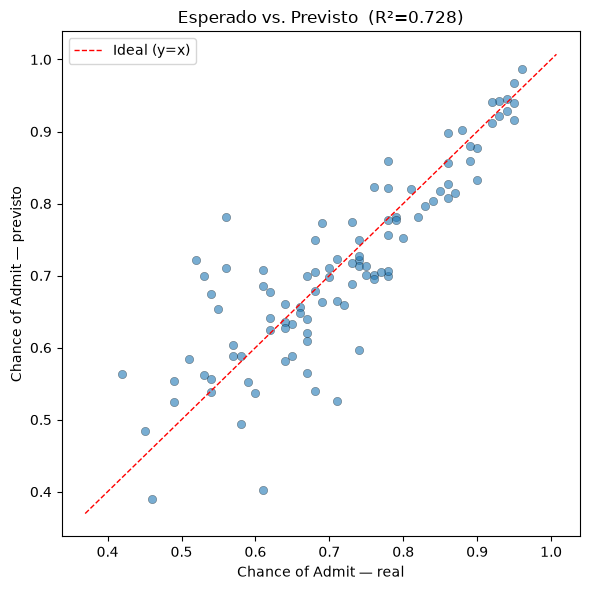

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()) - 0.02,
        max(y_test.max(), y_pred.max()) + 0.02]
plt.plot(lims, lims, 'r--', linewidth=1, label='Ideal (y=x)')
plt.xlabel('Chance of Admit — real')
plt.ylabel('Chance of Admit — previsto')
plt.title(f'Esperado vs. Previsto  (R²={test_r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()